===== 先验 = 正则化的数值验证 =====
lambda = sigma^2 / sigma_x^2 = 0.0100
MAP 处梯度范数（应为0）: 3.42e-13
闭式解 x_Tikh = y/(1+lambda) 已验证

含噪  MSE: 0.0101, PSNR: 19.97 dB
Tikh  MSE: 0.0099, PSNR: 20.05 dB
Lasso MSE: 0.0099, PSNR: 20.05 dB


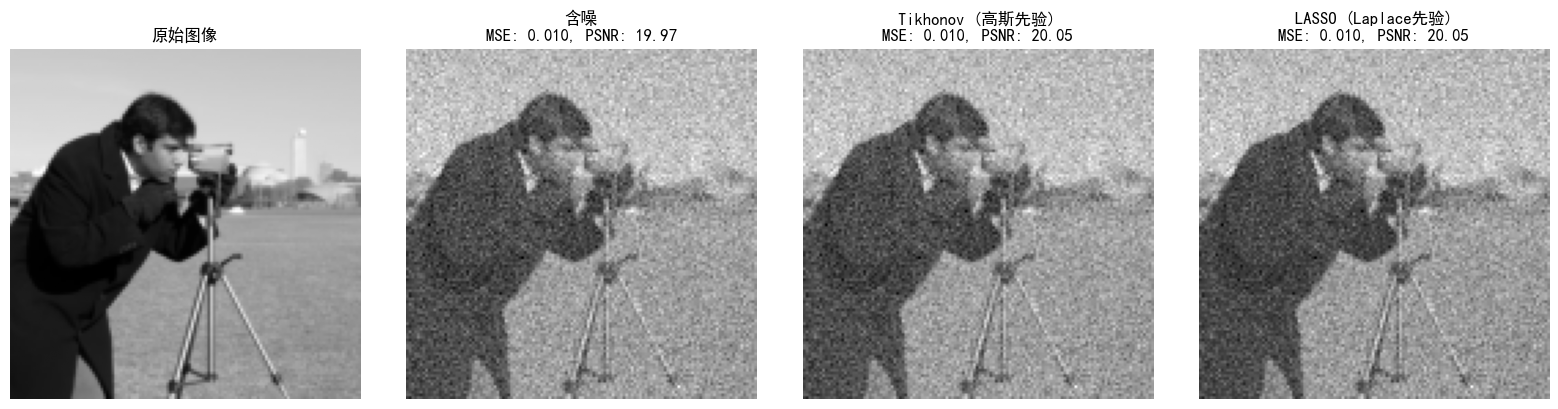

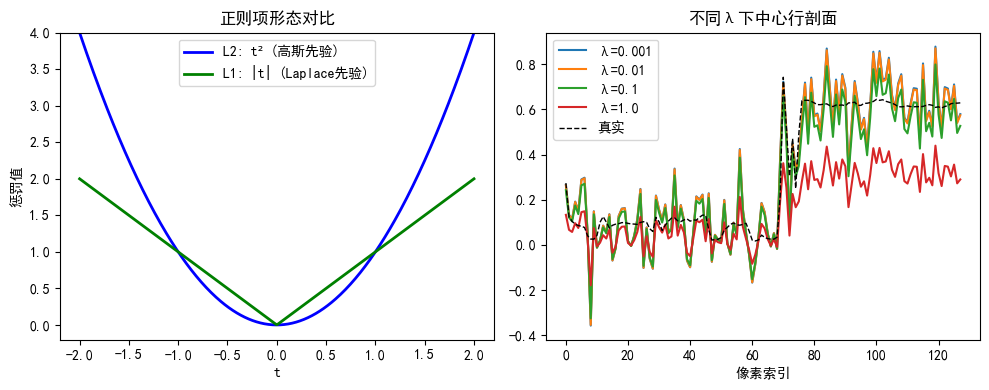

In [3]:
"""
实验2.1 先验与正则化的数值验证
对应章节：2.1 先验的数学角色：正则化的概率诠释
知识点：贝叶斯定理；先验→正则化对应关系；-ln p(x|y) = 数据项 + 正则项；λ = σ²/σ_x²

素材来源：
  - M1 CompImLab25.ipynb: Tikhonov闭式解 + LASSO软阈值
  - IP22 statistical_perspective.md: 高斯先验MAP推导
"""

import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio

plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# ====== 来源: M1 (CompImLab25.ipynb) ======
# 加载图像，转为灰度，加噪，Tikhonov + LASSO 去噪

# 加载并裁剪图像 (M1 使用 MNIST，这里用 cameraman)
n = 128
x = resize(data.camera(), (n, n))

# 加噪 (M1: noise_lev = 1e-1)
noise_lev = 1e-1
y = x + noise_lev * np.random.randn(n, n)

# Tikhonov 闭式解 (M1: x_Tikh = y/(1+lambda_Tikh))
# 先验: 高斯 x ~ N(0, sigma_x^2 I), 似然: y|x ~ N(x, sigma^2 I)
# -ln p(x|y) = 1/(2*sigma^2) ||y-x||^2 + 1/(2*sigma_x^2) ||x||^2 + const
# MAP 解: x_hat = y / (1 + lambda), lambda = sigma^2 / sigma_x^2
sigma = noise_lev
sigma_x = 1.0  # 高斯先验标准差
lambda_Tikh = sigma**2 / sigma_x**2
x_Tikh = y / (1 + lambda_Tikh)

# LASSO 软阈值 (M1: soft_thresh 函数)
# 先验: Laplace x ~ Laplace(0, b I)
# -ln p(x|y) = 1/(2*sigma^2) ||y-x||^2 + 1/b ||x||_1 + const
# MAP 解: x_hat = ST(y, lambda_lasso), lambda_lasso = sigma^2 / b
def soft_thresh(x, l):
    """软阈值函数 (来源: M1 CompImLab25.ipynb)"""
    return np.multiply(np.sign(x), np.maximum(np.abs(x) - l, np.zeros_like(x)))

b_laplace = 0.5
lambda_Lasso = sigma**2 / b_laplace
x_Lasso = soft_thresh(y, lambda_Lasso)

# ====== 验证: -ln p(x|y) = 数据项 + 正则项 ======
# 来源: IP22 推导

# 高斯先验下取 x = x_true，逐项计算
data_term = 0.5 / sigma**2 * np.sum((y - x)**2)
reg_term_gauss = 0.5 / sigma_x**2 * np.sum(x**2)
posterior_energy = data_term + reg_term_gauss

# 用 MAP 解验证: 最小化后验能量应得到 Tikhonov 解
# 对高斯先验，MAP = MMSE（后验对称）
# 验证: 梯度 = 0 => -1/sigma^2 * (y-x) + 1/sigma_x^2 * x = 0
# => x = sigma_x^2 / (sigma_x^2 + sigma^2) * y = y / (1 + lambda)
grad_at_map = -1/sigma**2 * (y - x_Tikh) + 1/sigma_x**2 * x_Tikh
print("===== 先验 = 正则化的数值验证 =====")
print(f"lambda = sigma^2 / sigma_x^2 = {lambda_Tikh:.4f}")
print(f"MAP 处梯度范数（应为0）: {np.linalg.norm(grad_at_map):.2e}")
print(f"闭式解 x_Tikh = y/(1+lambda) 已验证")

# ====== M1 度量 (M1: MSE + PSNR) ======
Orig_MSE = mean_squared_error(x, y)
Tikh_MSE = mean_squared_error(x, x_Tikh)
Lasso_MSE = mean_squared_error(x, x_Lasso)
Orig_PSNR = peak_signal_noise_ratio(x, y)
Tikh_PSNR = peak_signal_noise_ratio(x, x_Tikh)
Lasso_PSNR = peak_signal_noise_ratio(x, x_Lasso)

print(f"\n含噪  MSE: {Orig_MSE:.4f}, PSNR: {Orig_PSNR:.2f} dB")
print(f"Tikh  MSE: {Tikh_MSE:.4f}, PSNR: {Tikh_PSNR:.2f} dB")
print(f"Lasso MSE: {Lasso_MSE:.4f}, PSNR: {Lasso_PSNR:.2f} dB")

# ====== 可视化 (M1 风格) ======
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].imshow(x, cmap='gray')
axs[0].set_title('原始图像')

axs[1].imshow(y, cmap='gray')
axs[1].set_title(f'含噪\nMSE: {Orig_MSE:.3f}, PSNR: {Orig_PSNR:.2f}')

axs[2].imshow(x_Tikh, cmap='gray')
axs[2].set_title(f'Tikhonov (高斯先验)\nMSE: {Tikh_MSE:.3f}, PSNR: {Tikh_PSNR:.2f}')

axs[3].imshow(x_Lasso, cmap='gray')
axs[3].set_title(f'LASSO (Laplace先验)\nMSE: {Lasso_MSE:.3f}, PSNR: {Lasso_PSNR:.2f}')

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.savefig('2_1_result.png', dpi=150, bbox_inches='tight')
plt.show()

# ====== 正则项形态对比 ======
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

t = np.linspace(-2, 2, 400)
axes[0].plot(t, t**2, 'b-', linewidth=2, label='L2: t² (高斯先验)')
axes[0].plot(t, np.abs(t), 'g-', linewidth=2, label='L1: |t| (Laplace先验)')
axes[0].set_title('正则项形态对比')
axes[0].legend()
axes[0].set_xlabel('t')
axes[0].set_ylabel('惩罚值')
axes[0].set_ylim(-0.2, 4)

# 不同 lambda 下的解 (高斯先验)
lambdas = [0.001, 0.01, 0.1, 1.0]
center_row = n // 2
for lam_val in lambdas:
    x_hat = y / (1 + lam_val)
    axes[1].plot(x_hat[center_row, :], linewidth=1.5, label=f'λ={lam_val}')
axes[1].plot(x[center_row, :], 'k--', linewidth=1, label='真实')
axes[1].set_title('不同λ下中心行剖面')
axes[1].legend()
axes[1].set_xlabel('像素索引')

plt.tight_layout()
plt.savefig('2_1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
